# Model Training and Evaluation

After completing data preprocessing, feature engineering, and feature selection, machine learning models are trained to predict football match outcomes.

Since this is a multiclass classification problem, several classification algorithms are evaluated and compared. The models are assessed using common classification metrics to determine which one generalizes best to unseen data.

The following steps are performed:

1. Split the dataset into training and testing sets.
2. Train multiple classification models.
3. Evaluate each model using classification metrics.
4. Compare the performance of all models.

## Import Libraries

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

sns.set_theme(style="whitegrid")

## Load Dataset

In [20]:
df_selected = pd.read_csv("../data/feature_engineered_data.csv")

df_selected.head()

,match_result,home_club,away_club,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,...,home_goal_difference,away_goal_difference,rating_difference,goal_difference_difference,home_avg_rest_days,away_avg_rest_days,home_recent_home_ratio,away_recent_home_ratio,home_recent_cup_ratio,away_recent_cup_ratio
0,0,5943,7204,618,636,0,468196.0,468200.0,0.0,1.0,...,0.3,0.7,-3.064844,-0.4,48.1,35.0,0.5,0.6,0.0,0.5
1,2,7001,2429,512,752,0,516788.0,22169161.0,1.0,0.0,...,-0.1,-0.6,3.153522,0.5,33.5,39.0,0.5,0.5,0.0,0.0
2,1,8814,5417,373,734,0,2510608.0,456313.0,0.0,1.0,...,0.2,1.0,-0.775358,-0.8,42.0,46.0,0.5,0.5,0.0,0.0
3,0,4959,5753,370,743,0,1552508.0,465797.0,0.0,0.0,...,0.5,0.4,1.631795,0.1,34.7,34.6,0.5,0.5,0.0,0.1
4,2,2056,4246,373,705,0,429958.0,426870.0,0.0,1.0,...,0.4,0.8,1.096297,-0.4,34.8,34.8,0.5,0.6,0.0,0.0


## Train, Validation, and Test Split

The dataset is divided into three subsets:

- **Training set (70%)** for training the models.
- **Validation set (15%)** for model selection and hyperparameter tuning.
- **Test set (15%)** for evaluating the final model on unseen data.

A stratified split is used to preserve the original distribution of the target classes in all subsets.

In [21]:
X = df_selected.drop(columns=["match_result"])
y = df_selected["match_result"]

# Split into training (70%) and temporary (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Training Set:   {X_train.shape}")
print(f"Validation Set: {X_val.shape}")
print(f"Test Set:       {X_test.shape}")

Training Set:   (77644, 207)
Validation Set: (16638, 207)
Test Set:       (16639, 207)


## Logistic Regression

In [22]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

c:\Users\sarag\projects\Football_Match_Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Decision Tree

In [23]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

## Random Forest

In [24]:
rf = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## KNN

In [25]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [26]:
def evaluate(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1": f1_score(y_true, y_pred, average="weighted")
    }

In [27]:
results = pd.DataFrame({
    "Logistic Regression": evaluate(y_test, lr_pred),
    "Decision Tree": evaluate(y_test, dt_pred),
    "Random Forest": evaluate(y_test, rf_pred),
    "KNN": evaluate(y_test, knn_pred)
}).T

results

,Accuracy,Precision,Recall,F1
Logistic Regression,0.433319,0.302857,0.433319,0.268796
Decision Tree,0.382355,0.383179,0.382355,0.382754
Random Forest,0.429353,0.414985,0.429353,0.419899
KNN,0.361560,0.365487,0.361560,0.360974


In [28]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.40      0.43      0.42      5276
           1       0.27      0.19      0.22      4147
           2       0.51      0.56      0.53      7216

    accuracy                           0.43     16639
   macro avg       0.39      0.40      0.39     16639
weighted avg       0.41      0.43      0.42     16639



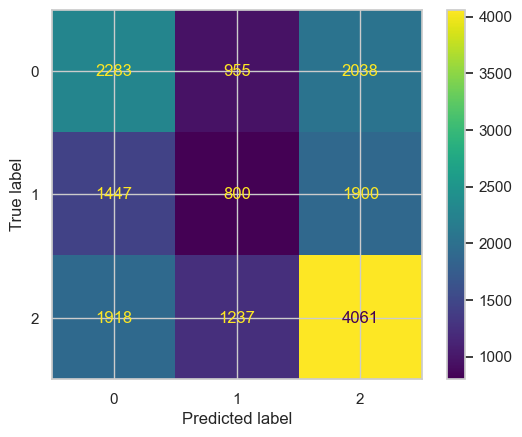

In [29]:
ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

In [30]:
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.43114469300990804
